In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv('//content//drive//MyDrive//heart.csv')

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.shape

(918, 12)

In [ ]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
# Putting feature variable to X
X = df.drop('HeartDisease',axis=1)
# Putting response variable to y
y = df['HeartDisease']

In [ ]:
# now lets split the data into train and test
from sklearn.model_selection import train_test_split
# Splitting the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)
X_train.shape, X_test.shape

((734, 11), (184, 11))

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [ ]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

classifier_rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    max_depth=5,
    n_estimators=100,
    oob_score=True
)

classifier_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_jobs=-1, oob_score=True, random_state=42)

In [ ]:
# checking the oob score
classifier_rf.oob_score_

0.8623978201634878

In [ ]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
params = {
    'max_depth': [2,3,5,10,20],
    'min_samples_leaf': [5,10,20,50,100,200],
    'n_estimators': [10,25,30,50,100,200]
}
from sklearn.model_selection import GridSearchCV
# Instantiate the grid search model
grid_search = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 4,
                           n_jobs=-1, verbose=1, scoring="accuracy")
#%%time
grid_search.fit(X_train, y_train)

Fitting 4 folds for each of 180 candidates, totalling 720 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_leaf': [5, 10, 20, 50, 100, 200],
                         'n_estimators': [10, 25, 30, 50, 100, 200]},
             scoring='accuracy', verbose=1)

In [ ]:
grid_search.best_score_

np.float64(0.873247802328344)

In [ ]:
rf_best = grid_search.best_estimator_
rf_best

RandomForestClassifier(max_depth=10, min_samples_leaf=5, n_estimators=30,
                       n_jobs=-1, random_state=42)

[Text(0.38853092783505155, 0.9545454545454546, 'ExerciseAngina_N <= 0.5\ngini = 0.492\nsamples = 465\nvalue = [320, 414]\nclass = No Disease'),
 Text(0.14304123711340205, 0.8636363636363636, 'Cholesterol <= 175.0\ngini = 0.267\nsamples = 197\nvalue = [51, 271]\nclass = No Disease'),
 Text(0.2657860824742268, 0.9090909090909092, 'True  '),
 Text(0.08247422680412371, 0.7727272727272727, 'FastingBS <= 0.5\ngini = 0.044\nsamples = 53\nvalue = [2, 87]\nclass = No Disease'),
 Text(0.061855670103092786, 0.6818181818181818, 'Cholesterol <= 65.5\ngini = 0.078\nsamples = 28\nvalue = [2.0, 47.0]\nclass = No Disease'),
 Text(0.041237113402061855, 0.5909090909090909, 'ChestPainType_ASY <= 0.5\ngini = 0.102\nsamples = 22\nvalue = [2, 35]\nclass = No Disease'),
 Text(0.020618556701030927, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [0, 9]\nclass = No Disease'),
 Text(0.061855670103092786, 0.5, 'gini = 0.133\nsamples = 16\nvalue = [2, 26]\nclass = No Disease'),
 Text(0.08247422680412371, 0.5909090909090909

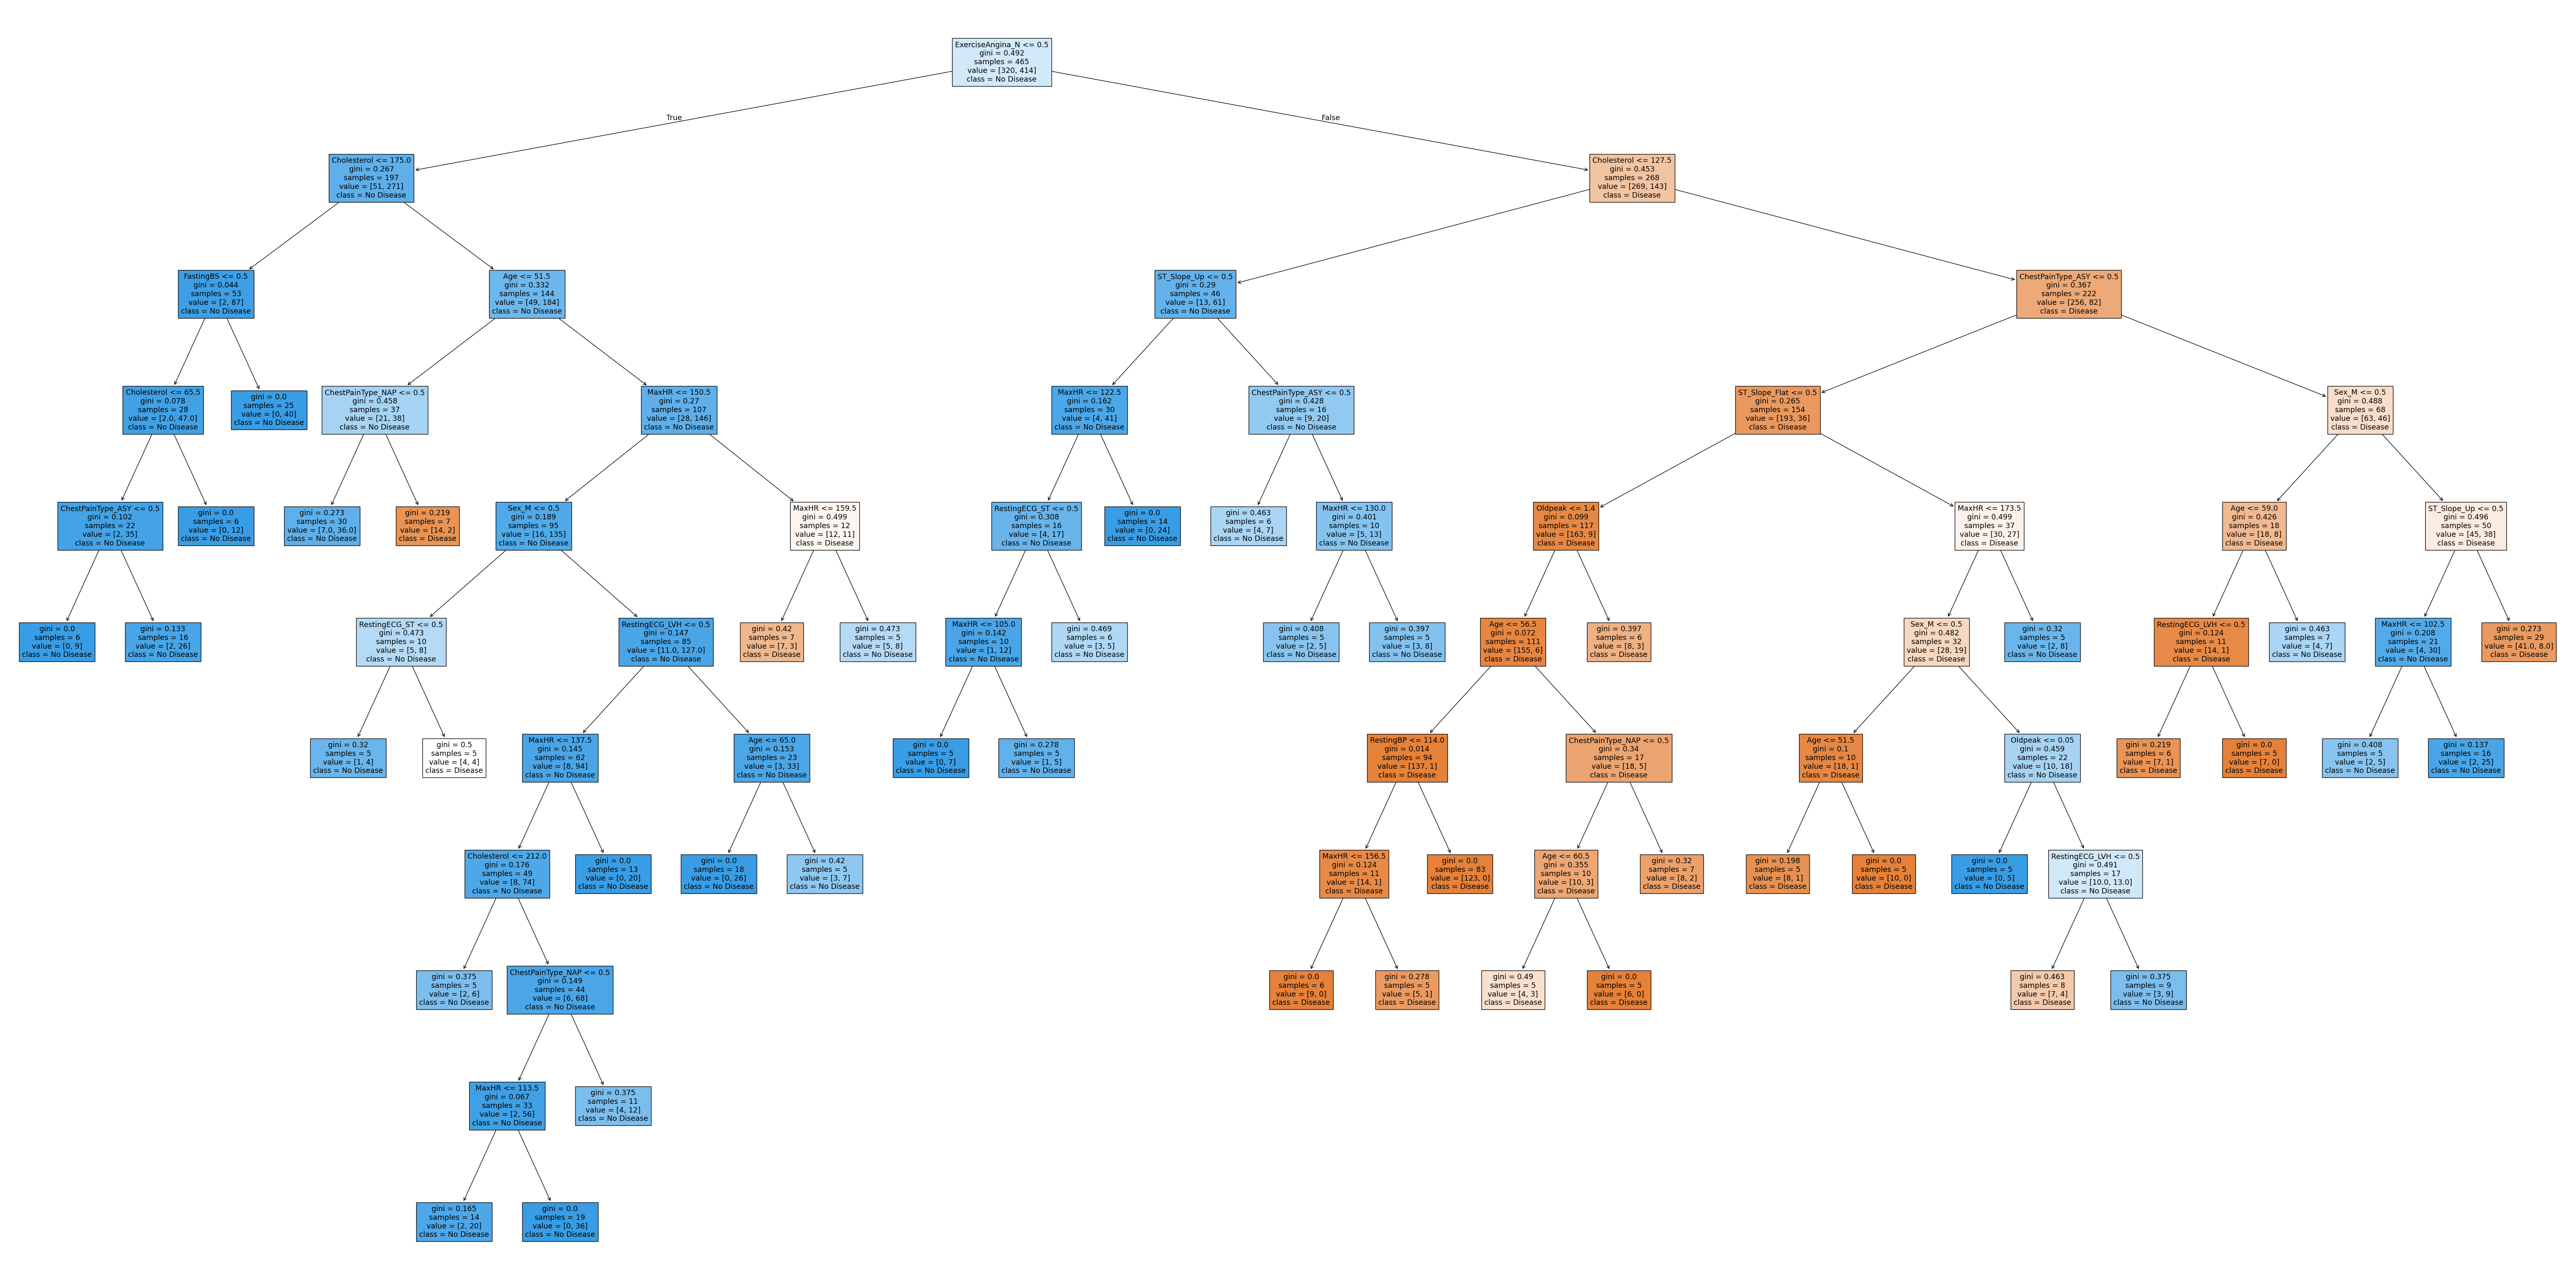

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(80,40))
plot_tree(
    rf_best.estimators_[5],
    feature_names=X_train.columns,
    class_names=['Disease','No Disease'],
    filled=True
)

In [ ]:
rf_best.feature_importances_

array([0.05550268, 0.02623668, 0.08029934, 0.01410444, 0.04176676,
       0.1113193 , 0.02211463, 0.01613335, 0.07698892, 0.01074226,
       0.00827414, 0.0011556 , 0.00951312, 0.00688917, 0.00277066,
       0.09527228, 0.08028376, 0.00806749, 0.10405234, 0.22851305])

In [ ]:
## feature importance

imp_df = pd.DataFrame({
    "Varname": X_train.columns,
    "Imp": rf_best.feature_importances_
})

In [ ]:
imp_df.sort_values(by="Imp", ascending=False)


,Varname,Imp
19,ST_Slope_Up,0.228513
5,Oldpeak,0.111319
18,ST_Slope_Flat,0.104052
15,ExerciseAngina_N,0.095272
2,Cholesterol,0.080299
16,ExerciseAngina_Y,0.080284
8,ChestPainType_ASY,0.076989
0,Age,0.055503
4,MaxHR,0.041767
1,RestingBP,0.026237
